In [1]:
!python -V

Python 3.13.9


In [1]:
import pandas as pd

In [2]:
import pickle

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [5]:
df = pd.read_parquet('yellow_tripdata_2025-01.parquet').head(100000)

df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds()/60 )

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

print(df[categorical])

      PULocationID DOLocationID
0              229          237
1              236          237
2              141          141
3              244          244
4              244          116
...            ...          ...
99995          186           50
99996          246          164
99997          230           88
99998           48          263
99999          263          141

[97571 rows x 2 columns]


In [6]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

5.686326519966899

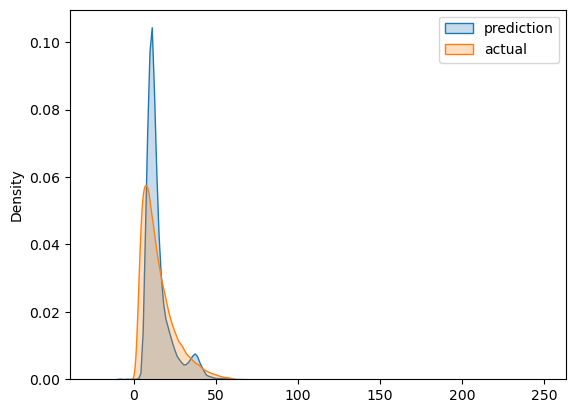

In [7]:
sns.kdeplot(y_pred, label='prediction', fill=True)
sns.kdeplot(y_train, label='actual', fill=True)

plt.legend()
plt.show()

In [8]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename).head(100000)

        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename).head(100000)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [9]:
df_train = read_dataframe('yellow_tripdata_2023-01.parquet')
df_val = read_dataframe('yellow_tripdata_2023-02.parquet')

In [10]:
len(df_train), len(df_val)

(97820, 98003)

In [11]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [12]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [13]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.284600942857191

In [15]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [16]:
import mlflow
import os

# Get the absolute path to the current directory's db file
db_path = os.path.abspath("mlflow.db") 
mlflow.set_tracking_uri(f"sqlite:////{db_path}")
mlflow.set_experiment("nyc-taxi-experiment")

with mlflow.start_run():

    mlflow.set_tag("developer", "suthagar")

    mlflow.log_param("train-data-path", "yellow_tripdata_2023-01.parquet")
    mlflow.log_param("valid-data-path", "yellow_tripdata_2023-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

In [17]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=10,
            evals=[(valid, 'validation')],
            early_stopping_rounds=5
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)
        mlflow.xgboost.log_model(xgb_model=booster, name="models_mlflow")

    return {'loss': rmse, 'status': STATUS_OK}

search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:squarederror',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=Trials()
)

/home/codespace/anaconda3/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


[0]	validation-rmse:8.03042                                                                                                           
[1]	validation-rmse:7.01837                                                                                                           
[2]	validation-rmse:6.46805                                                                                                           
[3]	validation-rmse:6.16449                                                                                                           
[4]	validation-rmse:6.00079                                                                                                           
[5]	validation-rmse:5.91727                                                                                                           
[6]	validation-rmse:5.86542                                                                                                           
[7]	validation-rmse:5.83539                            

In [ ]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

Best Run ID: da5f5f49672145688041f12a47aa2a94


Model loaded successfully!


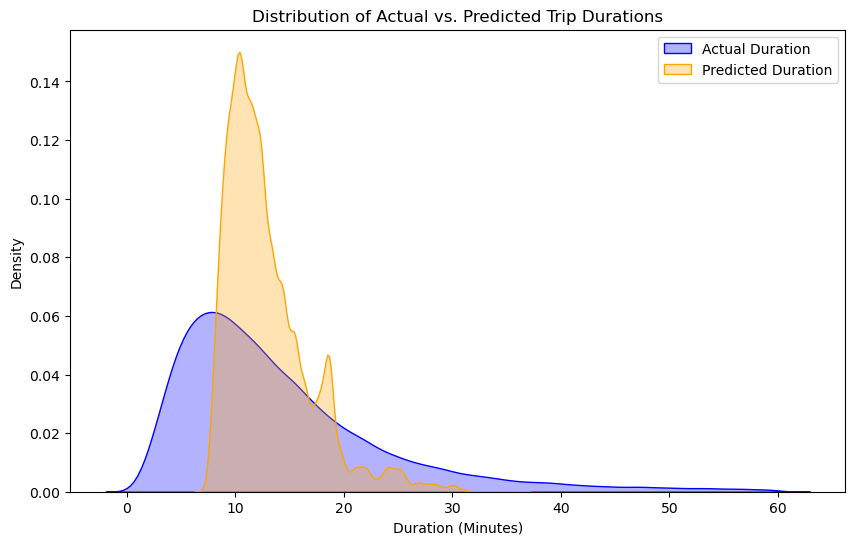

In [26]:
# 1. Ensure the tracking URI matches your local setup
mlflow.set_tracking_uri("sqlite:///mlflow.db")

experiment = mlflow.get_experiment_by_name("nyc-taxi-experiment")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], order_by=["metrics.rmse ASC"])
run_id = runs.iloc[0].run_id
print(f"Best Run ID: {run_id}")

# 2. Use the exact Run ID from your screenshot
run_id = "08df4670853740b887ab697868cf3643"

# 3. Construct the URI using the path shown in your 'Models' column
model_uri = f"runs:/{run_id}/models_mlflow"

# 4. Load as a pyfunc
model = mlflow.pyfunc.load_model(model_uri)

print("Model loaded successfully!")

# 5. Predict (ensure X_val is a DataFrame or NumPy array)
predictions = model.predict(X_val)

plt.figure(figsize=(10, 6))

# Plotting the actual vs predicted distributions
sns.kdeplot(y_val, label='Actual Duration', color='blue', fill=True, alpha=0.3)
sns.kdeplot(predictions, label='Predicted Duration', color='orange', fill=True, alpha=0.3)

plt.title("Distribution of Actual vs. Predicted Trip Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()